# Métricas de clasificación

En el cuaderno anterior usamos la **exactitud** (proporción de casos predichos correctamente) para medir el modelo. Pero la exactitud no lo es todo.

**El problema de la exactitud.** Supón que solo el 3% de la población es diabética. Podrías crear un clasificador que **siempre prediga 0** y tendría un 97% de exactitud — sin servir absolutamente para nada a la hora de identificar pacientes con diabetes.

Aquí vemos alternativas que revelan mucho más sobre cómo se comporta el modelo.

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Cargar datos, dividir y entrenar (igual que en el cuaderno 01)
diabetes = pd.read_csv('../datasets/diabetes.csv')

features = ['Pregnancies','PlasmaGlucose','DiastolicBloodPressure','TricepsThickness',
            'SerumInsulin','BMI','DiabetesPedigree','Age']
label = 'Diabetic'
X, y = diabetes[features].values, diabetes[label].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=0)
print(f'Entrenamiento: {X_train.shape[0]} · Prueba: {X_test.shape[0]}')

reg = 0.01
model = LogisticRegression(C=1/reg, solver='liblinear').fit(X_train, y_train)
predictions = model.predict(X_test)

print('Exactitud:', accuracy_score(y_test, predictions))

Entrenamiento: 10500 · Prueba: 4500
Exactitud: 0.7893333333333333


## El informe de clasificación

El punto de partida más simple para ir más allá de la exactitud.

In [2]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions, digits=4))

              precision    recall  f1-score   support

           0     0.8147    0.8835    0.8477      2986
           1     0.7242    0.6037    0.6585      1514

    accuracy                         0.7893      4500
   macro avg     0.7695    0.7436    0.7531      4500
weighted avg     0.7843    0.7893    0.7840      4500



El informe incluye, **para cada clase** (0 y 1):

| Métrica | Qué responde |
|---|---|
| **Precisión** | De las predicciones que el modelo hizo para esta clase, ¿qué proporción acertó? |
| **Recall** | De todas las instancias reales de esta clase, ¿cuántas identificó el modelo? |
| **F1-Score** | Métrica combinada que tiene en cuenta precisión y recall a la vez |
| **Support** | Cuántas instancias de esta clase hay en el conjunto de prueba |

También incluye promedios, entre ellos un promedio **ponderado** que compensa el desbalance en el número de casos de cada clase.

Como es un problema **binario**, la clase `1` se considera la *positiva*, y su precisión y recall son las interesantes. En concreto responden:

- De todos los pacientes que el modelo predijo diabéticos, ¿cuántos lo son realmente? → **precisión**
- De todos los pacientes que realmente son diabéticos, ¿cuántos identificó? → **recall**

In [3]:
from sklearn.metrics import precision_score, recall_score, f1_score

print('Precisión global:', precision_score(y_test, predictions))
print('Recall global   :', recall_score(y_test, predictions))
print('F1 global       :', f1_score(y_test, predictions))

Precisión global: 0.7242472266244057
Recall global   : 0.6036988110964333
F1 global       : 0.6585014409221902


## La matriz de confusión

Precisión y recall se derivan de cuatro resultados posibles:

- **Verdaderos positivos (TP)**: predicho 1, real 1.
- **Falsos positivos (FP)**: predicho 1, real 0.
- **Falsos negativos (FN)**: predicho 0, real 1.
- **Verdaderos negativos (TN)**: predicho 0, real 0.

Se tabulan juntos en una **matriz de confusión**:

| | Predicho 0 | Predicho 1 |
|---|---|---|
| **Real 0** | TN | FP |
| **Real 1** | FN | TP |

Las predicciones correctas forman la diagonal de arriba-izquierda a abajo-derecha. Si el modelo es bueno, esas cifras deben ser bastante mayores que las de fuera de la diagonal.

In [4]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)
print(cm)

[[2638  348]
 [ 600  914]]


Se suele dibujar como **mapa de calor**, donde la intensidad refleja el valor. En un modelo ideal se ve una diagonal oscura.

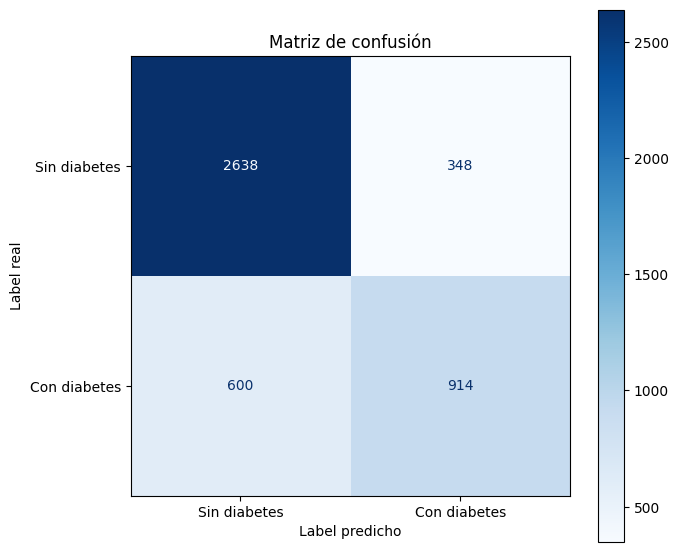

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay

clases = ['Sin diabetes', 'Con diabetes']

fig, ax = plt.subplots(figsize=(7,6))
ConfusionMatrixDisplay(cm, display_labels=clases).plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Matriz de confusión')
plt.ylabel('Label real')
plt.xlabel('Label predicho')
plt.tight_layout()
plt.show()

## Lo que realmente predice el modelo: probabilidades

Hasta ahora tratamos las predicciones como labels 0 o 1. En realidad es más sutil.

Los algoritmos estadísticos como la regresión logística se basan en **probabilidad**. Lo que un clasificador binario calcula de verdad es la probabilidad de que el label sea verdadero — `P(y)` — y la de que sea falso — `1 - P(y)`.

Un **umbral** de 0.5 decide si el label predicho es 1 (`P(y) > 0.5`) o 0 (`P(y) <= 0.5`). Con `predict_proba` se ven los pares de probabilidades de cada caso:

In [6]:
y_scores = model.predict_proba(X_test)
print('[P(clase 0), P(clase 1)] de los primeros 10 casos:')
print(np.round(y_scores[:10], 4))

[P(clase 0), P(clase 1)] de los primeros 10 casos:
[[0.8165 0.1835]
 [0.963  0.037 ]
 [0.8086 0.1914]
 [0.2411 0.7589]
 [0.3376 0.6624]
 [0.5532 0.4468]
 [0.9083 0.0917]
 [0.9269 0.0731]
 [0.3201 0.6799]
 [0.5496 0.4504]]


## Curva ROC

Si cambiáramos el umbral, cambiarían las predicciones y, con ellas, toda la matriz de confusión.

Una forma habitual de evaluar un clasificador es examinar la **tasa de verdaderos positivos** (otro nombre del recall) y la **tasa de falsos positivos** para *todos* los umbrales posibles. Al graficarlas una contra otra se obtiene la **curva ROC** (*Receiver Operating Characteristic*).

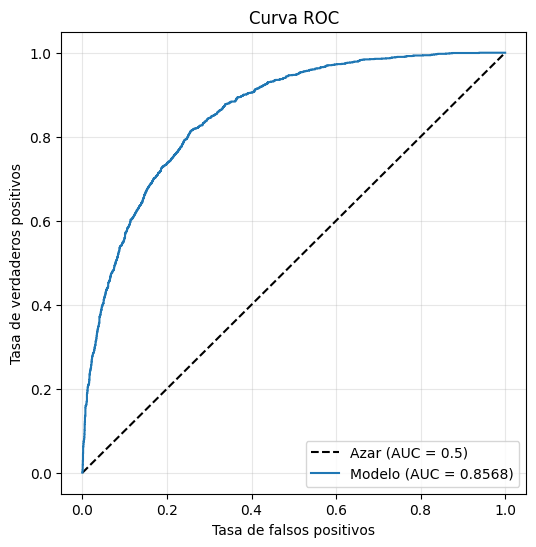

AUC: 0.8568482508863468


In [7]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_scores[:,1])
auc = roc_auc_score(y_test, y_scores[:,1])

fig = plt.figure(figsize=(6,6))
plt.plot([0,1], [0,1], 'k--', label='Azar (AUC = 0.5)')
plt.plot(fpr, tpr, label=f'Modelo (AUC = {auc:.4f})')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print('AUC:', auc)

La curva ROC muestra las tasas de verdaderos y falsos positivos para umbrales entre 0 y 1. Un clasificador perfecto subiría recto por el lado izquierdo y luego iría recto por arriba. La diagonal representa lo que se conseguiría prediciendo **al azar** — la curva debe quedar por encima de ella, o el modelo no sirve de nada.

El **área bajo la curva (AUC)** cuantifica el rendimiento global en un valor entre 0 y 1: cuanto más cerca de 1, mejor.

## Curva Precisión-Recall (PR)

> Esta sección **no está en el ejercicio original del curso**; se añade porque la curva PR es uno de los entregables pedidos.

La curva ROC tiene un punto débil: con clases **desbalanceadas** puede dar una impresión demasiado optimista, porque la tasa de falsos positivos se diluye entre muchos negativos.

La curva **precisión-recall** no usa los verdaderos negativos en ningún cálculo, así que refleja mejor el comportamiento sobre la clase positiva cuando esta es minoritaria. Su resumen numérico equivalente al AUC es la **precisión media** (*average precision*).

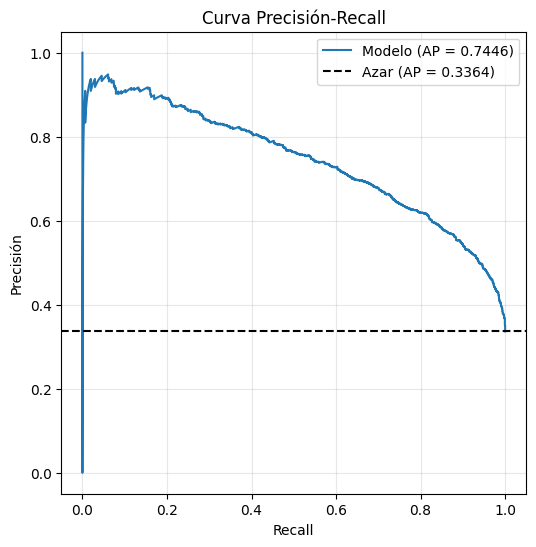

Precisión media (AP): 0.7446380782415188
Proporción de positivos en el conjunto de prueba: 0.3364


In [8]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_scores[:,1])
ap = average_precision_score(y_test, y_scores[:,1])

# Línea base: proporción de casos positivos en el conjunto de prueba
baseline = y_test.mean()

fig = plt.figure(figsize=(6,6))
plt.plot(recall_vals, precision_vals, label=f'Modelo (AP = {ap:.4f})')
plt.axhline(baseline, color='k', linestyle='--', label=f'Azar (AP = {baseline:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precisión')
plt.title('Curva Precisión-Recall')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print('Precisión media (AP):', ap)
print(f'Proporción de positivos en el conjunto de prueba: {baseline:.4f}')

> **Cómo leerla**: aquí la línea base del azar no es una diagonal sino una **horizontal** a la altura de la proporción de casos positivos. Cuanto más arriba y a la derecha quede la curva, mejor.

## Preprocesar dentro de un pipeline

Vamos a ver si mejora el modelo transformando los datos antes de entrenar:

- **Escalar** las features numéricas para que estén en la misma escala, evitando que las de valores grandes produzcan coeficientes que afecten desproporcionadamente.
- **Codificar** variables categóricas con one-hot.

Todo dentro de un **pipeline**, para que al predecir con datos nuevos se apliquen automáticamente las mismas transformaciones.

> **Ojo con una decisión del ejercicio original**: trata la columna `Age` (índice 7) como *categórica* y le aplica one-hot. Age es numérica, así que es una elección discutible — genera una columna binaria por cada edad distinta. Se mantiene igual que en el original para poder comparar, pero es el tipo de decisión que conviene cuestionar.

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numéricas: escalar
numeric_features = [0,1,2,3,4,5,6]
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

# 'Categóricas': one-hot sobre Age
categorical_features = [7]
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clasificador', LogisticRegression(C=1/reg, solver='liblinear'))
])

model_pipeline = pipeline.fit(X_train, y_train)
print(model_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  [0, 1, 2, 3, 4, 5, 6]),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  [7])])),
                ('clasificador',
                 LogisticRegression(C=100.0, solver='liblinear'))])


Comparemos sus métricas con las del modelo básico.

--- Regresión logística (baseline) ---
Matriz de confusión:
[[2638  348]
 [ 600  914]]
Exactitud : 0.7893
Precisión : 0.7242
Recall    : 0.6037
F1        : 0.6585
AUC (ROC) : 0.8568
AP (PR)   : 0.7446



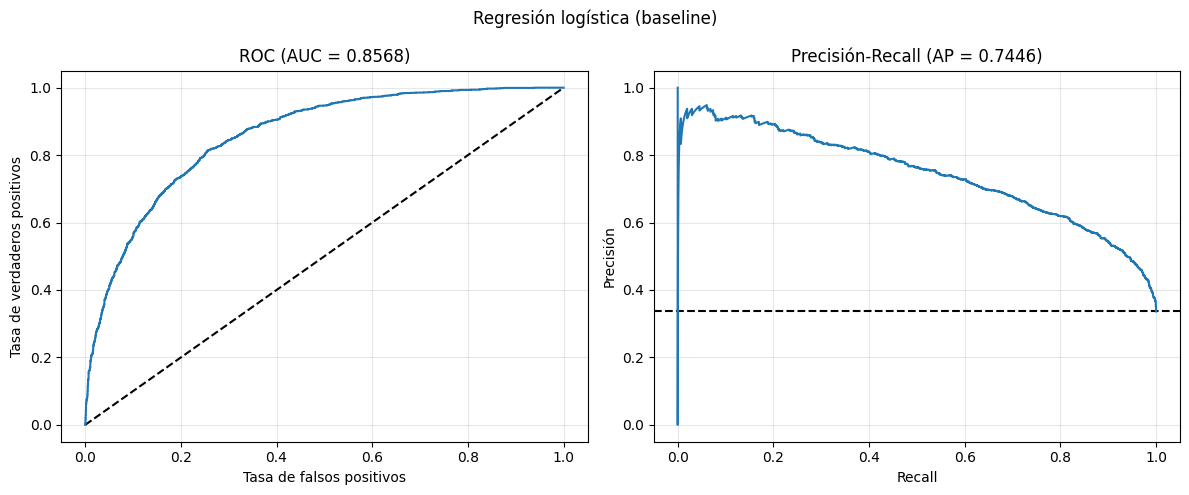

--- Regresión logística + preprocesamiento ---
Matriz de confusión:
[[2667  319]
 [ 406 1108]]
Exactitud : 0.8389
Precisión : 0.7765
Recall    : 0.7318
F1        : 0.7535
AUC (ROC) : 0.9202
AP (PR)   : 0.8554



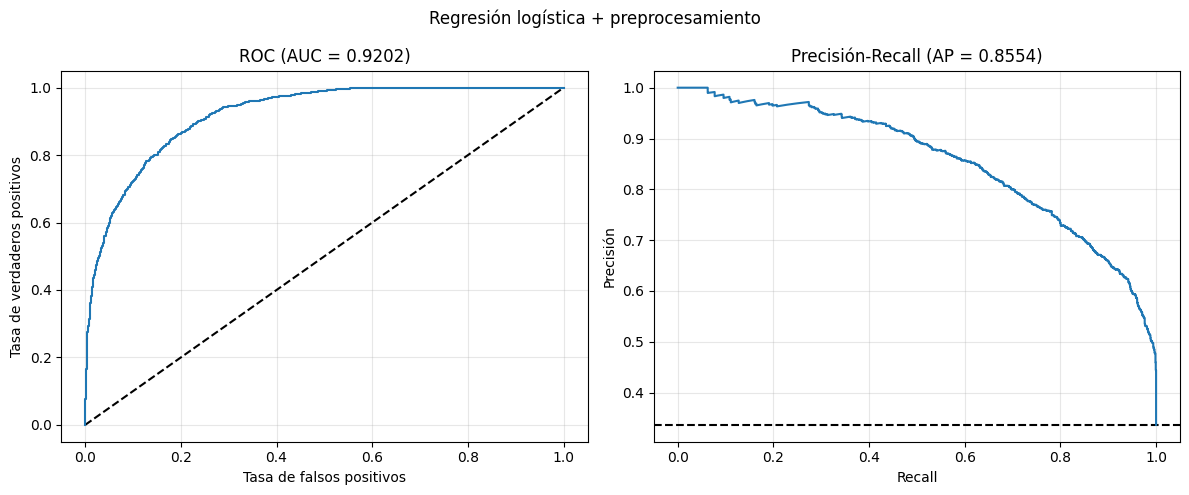

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('clasificador', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transfo

In [10]:
resultados = []

def evaluar(model, nombre, mostrar_grafico=True):
    """Evalúa un clasificador binario ya entrenado y registra sus métricas."""
    preds = model.predict(X_test)
    scores = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, scores)
    ap = average_precision_score(y_test, scores)

    print(f'--- {nombre} ---')
    print('Matriz de confusión:')
    print(confusion_matrix(y_test, preds))
    print(f'Exactitud : {acc:.4f}')
    print(f'Precisión : {prec:.4f}')
    print(f'Recall    : {rec:.4f}')
    print(f'F1        : {f1:.4f}')
    print(f'AUC (ROC) : {auc:.4f}')
    print(f'AP (PR)   : {ap:.4f}\n')

    if mostrar_grafico:
        fpr, tpr, _ = roc_curve(y_test, scores)
        pr_p, pr_r, _ = precision_recall_curve(y_test, scores)
        fig, ax = plt.subplots(1, 2, figsize=(12,5))
        ax[0].plot([0,1],[0,1],'k--'); ax[0].plot(fpr, tpr)
        ax[0].set_xlabel('Tasa de falsos positivos'); ax[0].set_ylabel('Tasa de verdaderos positivos')
        ax[0].set_title(f'ROC (AUC = {auc:.4f})'); ax[0].grid(alpha=0.3)
        ax[1].axhline(y_test.mean(), color='k', linestyle='--'); ax[1].plot(pr_r, pr_p)
        ax[1].set_xlabel('Recall'); ax[1].set_ylabel('Precisión')
        ax[1].set_title(f'Precisión-Recall (AP = {ap:.4f})'); ax[1].grid(alpha=0.3)
        fig.suptitle(nombre)
        plt.tight_layout(); plt.show()

    resultados.append({'modelo': nombre, 'Exactitud': acc, 'Precisión': prec,
                       'Recall': rec, 'F1': f1, 'AUC': auc, 'AP': ap})
    return model

# Modelo básico (sin preprocesamiento) para tener el punto de partida en la tabla
evaluar(model, 'Regresión logística (baseline)')
evaluar(model_pipeline, 'Regresión logística + preprocesamiento')

## Probar otro algoritmo

La regresión logística es un algoritmo **lineal**. Hay muchas otras familias de algoritmos de clasificación:

- **Máquinas de vectores de soporte (SVM)**: definen un *hiperplano* que separa las clases.
- **Basados en árboles**: construyen un árbol de decisión para llegar a la predicción.
- **De conjunto (ensemble)**: combinan las salidas de varios algoritmos base para generalizar mejor.

Usamos el mismo preprocesamiento pero cambiando el estimador por un **Random Forest**, que combina múltiples árboles de decisión aleatorios.

--- Random Forest + preprocesamiento ---
Matriz de confusión:
[[2857  129]
 [ 167 1347]]
Exactitud : 0.9342
Precisión : 0.9126
Recall    : 0.8897
F1        : 0.9010
AUC (ROC) : 0.9826
AP (PR)   : 0.9651



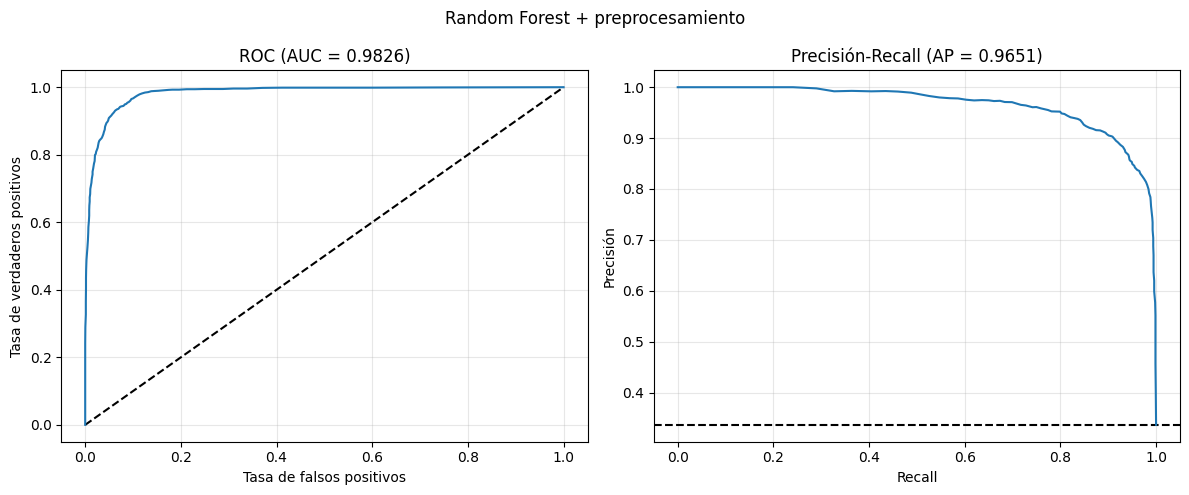

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('clasificador', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transfo

In [11]:
from sklearn.ensemble import RandomForestClassifier

pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clasificador', RandomForestClassifier(n_estimators=100, random_state=0))
])

model_rf = pipeline_rf.fit(X_train, y_train)
evaluar(model_rf, 'Random Forest + preprocesamiento')

## Comparativa

In [12]:
df_resultados = pd.DataFrame(resultados).sort_values('F1', ascending=False).reset_index(drop=True)
df_resultados.round(4)

,modelo,Exactitud,Precisión,Recall,F1,AUC,AP
0,Random Forest + preprocesamiento,0.9342,0.9126,0.8897,0.9010,0.9826,0.9651
1,Regresión logística + preprocesamiento,0.8389,0.7765,0.7318,0.7535,0.9202,0.8554
2,Regresión logística (baseline),0.7893,0.7242,0.6037,0.6585,0.8568,0.7446


## Guardar el modelo para usarlo después

Elegimos el mejor y lo serializamos, para poder cargarlo sin reentrenar (eso es la **inferencia**).

> El archivo `.pkl` **no se versiona** en el repositorio (está en el `.gitignore`): es un binario no revisable en un diff y atado a la versión de scikit-learn con la que se creó. Se regenera ejecutando esta celda.

In [13]:
import joblib

modelos = {
    'Regresión logística (baseline)': model,
    'Regresión logística + preprocesamiento': model_pipeline,
    'Random Forest + preprocesamiento': model_rf,
}

mejor_nombre = df_resultados.iloc[0]['modelo']
mejor_modelo = modelos[mejor_nombre]
print(f'Mejor modelo por F1: {mejor_nombre}')

filename = '../entregables/diabetes-model.pkl'
joblib.dump(mejor_modelo, filename)
print(f'Guardado en: {filename}')

Mejor modelo por F1: Random Forest + preprocesamiento
Guardado en: ../entregables/diabetes-model.pkl


In [14]:
# Cargar el modelo y predecir un caso nuevo
loaded = joblib.load(filename)

# [Pregnancies, PlasmaGlucose, DiastolicBP, TricepsThickness, SerumInsulin, BMI, DiabetesPedigree, Age]
X_new = np.array([[2, 180, 74, 24, 21, 23.9091702, 1.488172308, 22]])
print('Paciente nuevo:', list(X_new[0]))

pred = loaded.predict(X_new)[0]
proba = loaded.predict_proba(X_new)[0]
print(f'Clase predicha: {pred} ({clases[pred]})')
print(f'Probabilidades: sin diabetes {proba[0]:.4f} · con diabetes {proba[1]:.4f}')

Paciente nuevo: [np.float64(2.0), np.float64(180.0), np.float64(74.0), np.float64(24.0), np.float64(21.0), np.float64(23.9091702), np.float64(1.488172308), np.float64(22.0)]
Clase predicha: 1 (Con diabetes)
Probabilidades: sin diabetes 0.1000 · con diabetes 0.9000


## Resumen

Vimos un abanico de métricas para clasificación binaria y probamos algoritmos más allá de la regresión logística.

La idea a retener: **la exactitud sola es insuficiente**. Con clases desbalanceadas puede parecer excelente mientras el modelo ignora por completo la clase minoritaria. Precisión, recall, F1, y las curvas ROC y PR cuentan lo que la exactitud esconde.